── Task 3: A/B Hypothesis Testing ────────────────────────────────────────────
10 Academy KAIM-9 | Week 3

Objective: Statistically validate or reject four null hypotheses about
risk drivers, forming the evidence base for ACIS's new segmentation
and pricing strategy.

Risk is measured by:
- Claim Frequency  = proportion of policies with TotalClaims > 0
- Claim Severity   = mean TotalClaims among policies that had a claim
- Margin           = TotalPremium − TotalClaims

── 0. Setup ──────────────────────────────────────────────────────────────────

In [1]:
import sys, pathlib
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader       import load_data, engineer_base_features
from src.hypothesis_tests  import (
    compute_claim_frequency,
    compute_claim_severity,
    run_chi_squared,
    run_t_test,
    run_z_test,
    test_province_risk,
    test_zipcode_risk,
    test_zipcode_margin,
    test_gender_risk,
    summarise_results,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.float_format", "{:,.4f}".format)
ALPHA = 0.05

── 1. Load Data ───────────────────────────────────────────────────────────────
Load the dataset and compute LossRatio and Margin.

In [13]:
DATA_PATH = "../data/insurance_data.txt"
PLOTS_DIR   = "../plots"


df_raw = load_data(DATA_PATH)
df     = engineer_base_features(df_raw)

print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Claim rate: {(df['TotalClaims'] > 0).mean():.1%} of policies had a claim")

Dataset: 1,000,098 rows × 54 columns
Claim rate: 0.3% of policies had a claim


── 2. KPI Overview ────────────────────────────────────────────────────────────
Before running tests, inspect the portfolio-level KPIs.
This gives context for interpreting the group-level comparisons below.

In [5]:
portfolio_freq = compute_claim_frequency(df["TotalClaims"])
claimants      = df[df["TotalClaims"] > 0]["TotalClaims"]
portfolio_sev  = claimants.mean()
portfolio_margin = df["Margin"].mean()

print(f"\nPortfolio KPIs")
print(f"  Claim Frequency : {portfolio_freq:.2%}")
print(f"  Claim Severity  : ZAR {portfolio_sev:,.2f}")
print(f"  Avg Margin      : ZAR {portfolio_margin:,.2f}")
print(f"  Loss Ratio      : {df['LossRatio'].mean():.4f}")


Portfolio KPIs
  Claim Frequency : 0.28%
  Claim Severity  : ZAR 23,273.39
  Avg Margin      : ZAR -2.96
  Loss Ratio      : 0.3499


── 3. Hypothesis 1: Risk differences across Provinces ────────────────────────
H0: There are no risk differences across provinces.
KPI: Claim Severity (mean TotalClaims among claimants)
Test: Welch t-test on the two largest provinces by policy count.

We use claim severity because it captures the financial impact of a claim,
not just whether a claim occurred. Two provinces may have the same claim
frequency but very different claim amounts — that matters for pricing.


H1: Province Risk (Claim Severity)
  test                : Welch t-test
  statistic           : -2.1685
  p_value             : 0.030599
  alpha               : 0.05
  reject_h0           : True
  mean_a              : 22243.8784
  mean_b              : 28095.8499
  n_a                 : 1322
  n_b                 : 370
  hypothesis          : H0: No risk difference across provinces
  kpi                 : Claim Severity
  group_a             : Gauteng
  group_b             : Western Cape


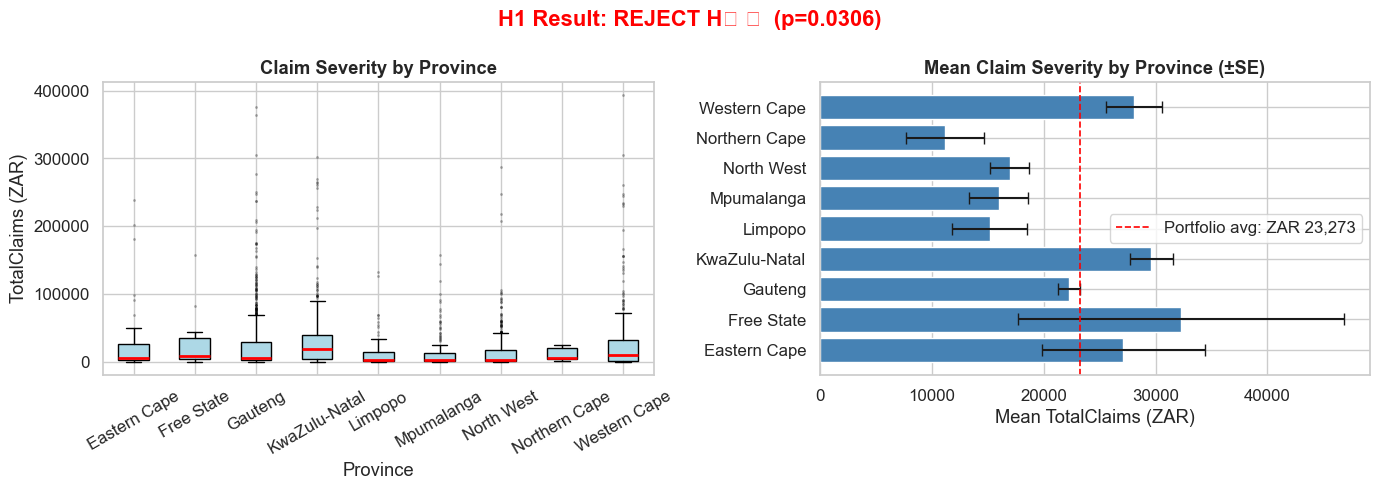

In [14]:
print("\n" + "="*60)
print("H1: Province Risk (Claim Severity)")
print("="*60)

result_province = test_province_risk(df, alpha=ALPHA)
for k, v in result_province.items():
    print(f"  {k:20s}: {v}")

# Visualise: Claim Severity distribution by province
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: box plot of severity by province
prov_col  = "Province"
claim_col = "TotalClaims"
severity_by_prov = (
    df[df[claim_col] > 0]
    .groupby(prov_col, observed=True)[claim_col]
    .apply(list)
)
axes[0].boxplot(
    [v for v in severity_by_prov.values],
    labels=severity_by_prov.index,
    patch_artist=True,
    medianprops=dict(color="red", lw=2),
    boxprops=dict(facecolor="lightblue"),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
)
axes[0].set_title("Claim Severity by Province", fontweight="bold")
axes[0].set_xlabel("Province")
axes[0].set_ylabel("TotalClaims (ZAR)")
axes[0].tick_params(axis="x", rotation=30)

# Right: mean severity bar chart with error bars
sev_summary = (
    df[df[claim_col] > 0]
    .groupby(prov_col, observed=True)[claim_col]
    .agg(["mean", "std", "count"])
    .reset_index()
)
sev_summary["se"] = sev_summary["std"] / np.sqrt(sev_summary["count"])
axes[1].barh(sev_summary[prov_col], sev_summary["mean"],
             xerr=sev_summary["se"], color="steelblue", edgecolor="white",
             capsize=4)
axes[1].axvline(portfolio_sev, color="red", linestyle="--", lw=1.2,
                label=f"Portfolio avg: ZAR {portfolio_sev:,.0f}")
axes[1].set_title("Mean Claim Severity by Province (±SE)", fontweight="bold")
axes[1].set_xlabel("Mean TotalClaims (ZAR)")
axes[1].legend()
plt.suptitle(
    f"H1 Result: {'REJECT H₀ ✗' if result_province['reject_h0'] else 'FAIL TO REJECT H₀ ✓'}  "
    f"(p={result_province['p_value']:.4f})",
    fontweight="bold", color="red" if result_province["reject_h0"] else "green"
)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/h1_result.png", dpi=150)

plt.show()

── 4. Hypothesis 2: Risk differences between Zip Codes ───────────────────────
H0: There are no risk differences between zip codes.
KPI: Claim Frequency (proportion of policies with a claim)
Test: Chi-squared test on the two most common postal codes.

Chi-squared is used here because the KPI is categorical (claim / no claim).
It tests whether the distribution of claims is independent of postal code.


H2: Zip Code Risk (Claim Frequency)
  test                : chi-squared
  statistic           : 3.5971
  p_value             : 0.057882
  alpha               : 0.05
  reject_h0           : False
  freq_a              : 0.0036
  freq_b              : 0.0043
  n_a                 : 133498
  n_b                 : 49171
  hypothesis          : H0: No risk difference between zip codes
  kpi                 : Claim Frequency
  group_a             : 2000
  group_b             : 122


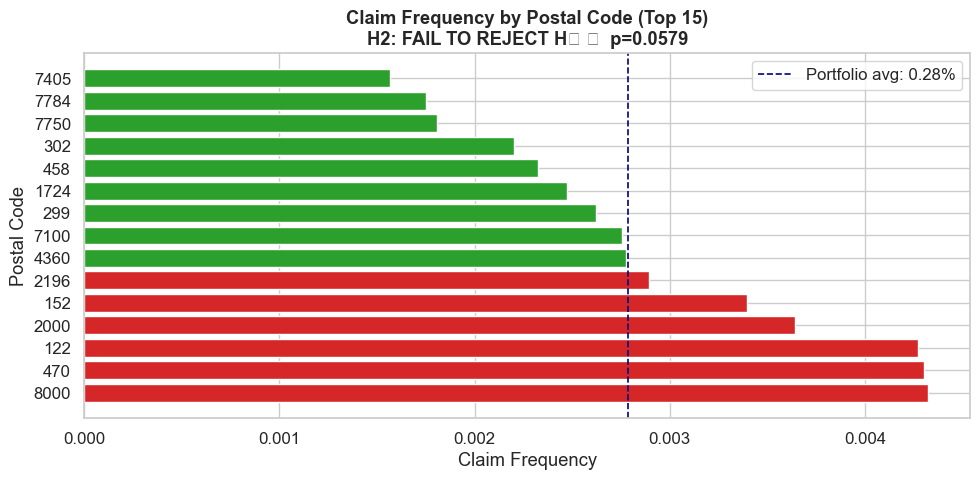

In [15]:
print("\n" + "="*60)
print("H2: Zip Code Risk (Claim Frequency)")
print("="*60)

result_zip_risk = test_zipcode_risk(df, alpha=ALPHA)
for k, v in result_zip_risk.items():
    print(f"  {k:20s}: {v}")

# Visualise: Claim frequency by top-15 postal codes
top_zips = df["PostalCode"].value_counts().head(15).index
zip_freq = (
    df[df["PostalCode"].isin(top_zips)]
    .groupby("PostalCode", observed=True)["TotalClaims"]
    .apply(lambda x: (pd.to_numeric(x, errors="coerce") > 0).mean())
    .sort_values(ascending=False)
    .reset_index()
)
zip_freq.columns = ["PostalCode", "ClaimFrequency"]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728" if v > portfolio_freq else "#2ca02c" for v in zip_freq["ClaimFrequency"]]
ax.barh(zip_freq["PostalCode"].astype(str), zip_freq["ClaimFrequency"],
        color=colors, edgecolor="white")
ax.axvline(portfolio_freq, color="navy", linestyle="--", lw=1.2,
           label=f"Portfolio avg: {portfolio_freq:.2%}")
ax.set_title(
    f"Claim Frequency by Postal Code (Top 15)\n"
    f"H2: {'REJECT H₀ ✗' if result_zip_risk['reject_h0'] else 'FAIL TO REJECT H₀ ✓'}  "
    f"p={result_zip_risk['p_value']:.4f}",
    fontweight="bold"
)
ax.set_xlabel("Claim Frequency")
ax.set_ylabel("Postal Code")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/claim_frequency_by_postal_code.png", dpi=150)

plt.show()

── 5. Hypothesis 3: Margin differences between Zip Codes ─────────────────────
H0: There is no significant margin difference between zip codes.
KPI: Margin = TotalPremium − TotalClaims
Test: Welch t-test on the two most common postal codes.

Margin is a continuous variable so t-test is the right choice.
A statistically significant difference means some zip codes are
systematically more or less profitable — a pricing signal.


H3: Zip Code Margin
  test                : Welch t-test
  statistic           : 1.1639
  p_value             : 0.244462
  alpha               : 0.05
  reject_h0           : False
  mean_a              : -8.1119
  mean_b              : -22.8598
  n_a                 : 133498
  n_b                 : 49171
  hypothesis          : H0: No margin difference between zip codes
  kpi                 : Margin (TotalPremium − TotalClaims)
  group_a             : 2000
  group_b             : 122


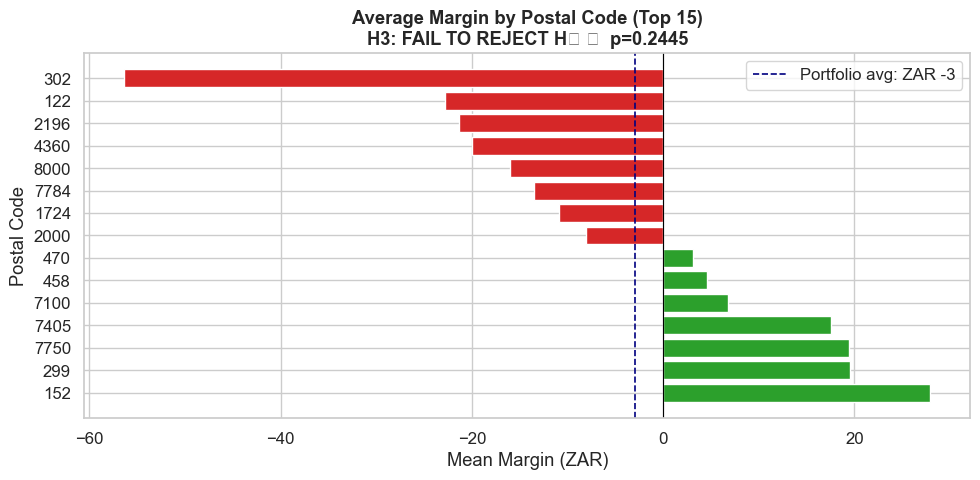

In [16]:
print("\n" + "="*60)
print("H3: Zip Code Margin")
print("="*60)

result_zip_margin = test_zipcode_margin(df, alpha=ALPHA)
for k, v in result_zip_margin.items():
    print(f"  {k:20s}: {v}")

# Visualise: Average margin by top-15 postal codes
zip_margin = (
    df[df["PostalCode"].isin(top_zips)]
    .groupby("PostalCode", observed=True)["Margin"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in zip_margin["Margin"]]
ax.barh(zip_margin["PostalCode"].astype(str), zip_margin["Margin"],
        color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.axvline(portfolio_margin, color="navy", linestyle="--", lw=1.2,
           label=f"Portfolio avg: ZAR {portfolio_margin:,.0f}")
ax.set_title(
    f"Average Margin by Postal Code (Top 15)\n"
    f"H3: {'REJECT H₀ ✗' if result_zip_margin['reject_h0'] else 'FAIL TO REJECT H₀ ✓'}  "
    f"p={result_zip_margin['p_value']:.4f}",
    fontweight="bold"
)
ax.set_xlabel("Mean Margin (ZAR)")
ax.set_ylabel("Postal Code")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/average_margin_by_postal_card.png", dpi=150)

plt.show()

── 6. Hypothesis 4: Risk differences between Genders ─────────────────────────
H0: There is no significant risk difference between Women and Men.
KPI: Claim Severity
Test: Welch t-test on Male vs Female subgroups.

We compare claim severity rather than frequency because insurers use
severity to set coverage limits. A significant severity difference
between genders provides quantitative evidence for or against
gender-differentiated risk pricing.


H4: Gender Risk (Claim Severity)
  test                : Welch t-test
  statistic           : -0.579
  p_value             : 0.568029
  alpha               : 0.05
  reject_h0           : False
  mean_a              : 14858.5523
  mean_b              : 17874.7213
  n_a                 : 94
  n_b                 : 14
  hypothesis          : H0: No risk difference between Women and Men
  kpi                 : Claim Severity
  group_a             : Male
  group_b             : Female


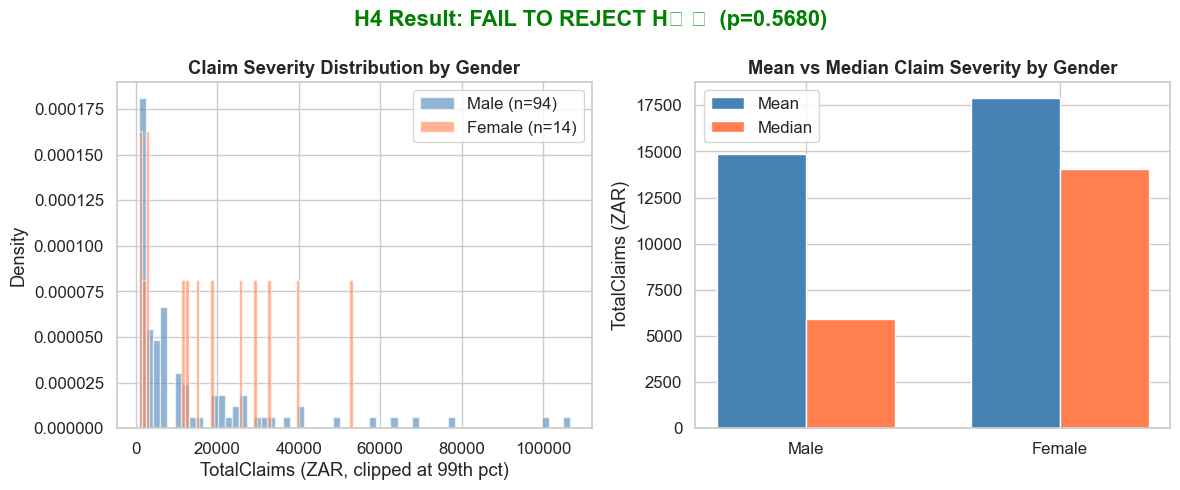

In [17]:
print("\n" + "="*60)
print("H4: Gender Risk (Claim Severity)")
print("="*60)

result_gender = test_gender_risk(df, alpha=ALPHA)
for k, v in result_gender.items():
    print(f"  {k:20s}: {v}")

# Visualise: Severity distribution by gender
gender_series = df["Gender"].astype(str).str.strip().str.lower()
male_sev   = df.loc[gender_series.str.contains("male") & ~gender_series.str.contains("fe"), "TotalClaims"]
female_sev = df.loc[gender_series.str.contains("fe"), "TotalClaims"]
male_sev   = pd.to_numeric(male_sev,   errors="coerce")
female_sev = pd.to_numeric(female_sev, errors="coerce")
male_sev   = male_sev[male_sev > 0]
female_sev = female_sev[female_sev > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(male_sev.clip(upper=male_sev.quantile(0.99)),
             bins=60, alpha=0.6, color="steelblue", label=f"Male (n={len(male_sev):,})", density=True)
axes[0].hist(female_sev.clip(upper=female_sev.quantile(0.99)),
             bins=60, alpha=0.6, color="coral", label=f"Female (n={len(female_sev):,})", density=True)
axes[0].set_title("Claim Severity Distribution by Gender", fontweight="bold")
axes[0].set_xlabel("TotalClaims (ZAR, clipped at 99th pct)")
axes[0].set_ylabel("Density")
axes[0].legend()

gender_means = pd.DataFrame({
    "Gender": ["Male", "Female"],
    "MeanSeverity": [male_sev.mean(), female_sev.mean()],
    "MedianSeverity": [male_sev.median(), female_sev.median()],
})
x = np.arange(2)
w = 0.35
axes[1].bar(x - w/2, gender_means["MeanSeverity"],   w, label="Mean",   color="steelblue")
axes[1].bar(x + w/2, gender_means["MedianSeverity"], w, label="Median", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Male", "Female"])
axes[1].set_title("Mean vs Median Claim Severity by Gender", fontweight="bold")
axes[1].set_ylabel("TotalClaims (ZAR)")

axes[1].legend()

plt.suptitle(
    f"H4 Result: {'REJECT H₀ ✗' if result_gender['reject_h0'] else 'FAIL TO REJECT H₀ ✓'}  "
    f"(p={result_gender['p_value']:.4f})",
    fontweight="bold",
    color="red" if result_gender["reject_h0"] else "green"
)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/claimseverity_by_gender.png", dpi=150)

plt.show()

── 7. Results Summary Table ───────────────────────────────────────────────────
Collect all four results into one table for the final report.

In [10]:
print("\n" + "="*60)
print("SUMMARY OF ALL HYPOTHESIS TESTS")
print("="*60)

summary = summarise_results(df, alpha=ALPHA)
print(summary.to_string(index=False))


SUMMARY OF ALL HYPOTHESIS TESTS
                                  hypothesis                                 kpi group_a      group_b         test  statistic  p_value  reject_h0          decision
     H0: No risk difference across provinces                      Claim Severity Gauteng Western Cape Welch t-test    -2.1685   0.0306       True         Reject H₀
    H0: No risk difference between zip codes                     Claim Frequency    2000          122  chi-squared     3.5971   0.0579      False Fail to reject H₀
  H0: No margin difference between zip codes Margin (TotalPremium − TotalClaims)    2000          122 Welch t-test     1.1639   0.2445      False Fail to reject H₀
H0: No risk difference between Women and Men                      Claim Severity    Male       Female Welch t-test    -0.5790   0.5680      False Fail to reject H₀


── 8. Business Interpretations ────────────────────────────────────────────────
For each rejected hypothesis, write a business-facing interpretation.

In [12]:
print("\nBUSINESS INTERPRETATIONS")
print("-"*60)

for _, row in summary.iterrows():
    status = "REJECTED" if row["reject_h0"] else "NOT REJECTED"
    print(f"\n[{status}] {row['hypothesis']}")
    print(f"  Test: {row['test']}  |  p-value: {row['p_value']:.4f}  |  α={ALPHA}")
    if row["reject_h0"]:
        print(f"  ➜ Evidence of a significant difference in {row['kpi']} between "
              f"{row['group_a']} and {row['group_b']}.")
        print(f"    Recommendation: consider segment-specific pricing adjustments.")
    else:
        print(f"  ➜ No statistically significant difference detected in {row['kpi']}.")
        print(f"    Recommendation: uniform pricing for this segment is statistically defensible.")




BUSINESS INTERPRETATIONS
------------------------------------------------------------

[REJECTED] H0: No risk difference across provinces
  Test: Welch t-test  |  p-value: 0.0306  |  α=0.05
  ➜ Evidence of a significant difference in Claim Severity between Gauteng and Western Cape.
    Recommendation: consider segment-specific pricing adjustments.

[NOT REJECTED] H0: No risk difference between zip codes
  Test: chi-squared  |  p-value: 0.0579  |  α=0.05
  ➜ No statistically significant difference detected in Claim Frequency.
    Recommendation: uniform pricing for this segment is statistically defensible.

[NOT REJECTED] H0: No margin difference between zip codes
  Test: Welch t-test  |  p-value: 0.2445  |  α=0.05
  ➜ No statistically significant difference detected in Margin (TotalPremium − TotalClaims).
    Recommendation: uniform pricing for this segment is statistically defensible.

[NOT REJECTED] H0: No risk difference between Women and Men
  Test: Welch t-test  |  p-value: 0.568